In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Use this ONLY in Jupyter Notebook



# ====== 🔹 Add your FITS files here ======
files = [
    '/Users/abishaj/Documents/Rajaguru/M_stars /YZ Ceti/spectrum_fits/r.HARPS.2003-12-13T02:16:29.935_S1D_A.fits',
    '/Users/abishaj/Documents/Rajaguru/M_stars /YZ Ceti/spectrum_fits/r.HARPS.2003-12-23T01:14:01.606_S1D_A.fits'
]


# ====== 🔹 Constants ======
h_alpha_center = 6562.8
ca_k_center = 3933.7
ca_h_center = 3968.5

zoom_window_ha = 20     # Å around Hα
zoom_window_ca = 30     # Å around Ca H&K


# ====== 🔹 Read FITS spectrum ======
def read_fits_spectrum(file):
    """Read wavelength and flux arrays from HARPS S1D or tabular FITS."""
    with fits.open(file) as hdul:
        hdr = hdul[0].header

        # HARPS S1D format
        if hdul[0].data is not None and 'CRVAL1' in hdr and 'CDELT1' in hdr:
            flux = hdul[0].data.astype(float)
            naxis1 = hdr['NAXIS1']
            crval1 = hdr['CRVAL1']
            cdelt1 = hdr['CDELT1']
            wavelength = crval1 + cdelt1 * np.arange(naxis1)

        # Tabular FITS
        elif len(hdul) > 1 and hasattr(hdul[1], 'columns'):
            data = hdul[1].data
            cols = hdul[1].columns.names

            if 'WAVE' in cols and 'FLUX' in cols:
                wavelength = data['WAVE'][0]
                flux = data['FLUX'][0]
            elif 'wavelength_air' in cols and 'flux' in cols:
                wavelength = data['wavelength_air']
                flux = data['flux']
            else:
                print(f"⚠️ Unknown table format in {file}")
                return None, None
        else:
            print(f"⚠️ Unsupported FITS format in {file}")
            return None, None

    return wavelength, flux


# ====== 🔹 Plot generic spectral region ======
def plot_region(center, window, title, line_color, line_label):
    plt.figure(figsize=(10, 6))

    for file in files:
        try:
            wavelength, flux = read_fits_spectrum(file)
            if wavelength is None:
                continue

            mask = (wavelength >= center - window) & (wavelength <= center + window)
            wl = wavelength[mask]
            fl = flux[mask]

            # Clean data
            valid = (~np.isnan(fl)) & (fl > 0)
            wl = wl[valid]
            fl = fl[valid]

            if len(fl) == 0:
                print(f"⚠️ No valid data in {file}")
                continue

            fl /= np.nanmax(fl)

            plt.plot(wl, fl, label=os.path.basename(file))

        except Exception as e:
            print(f"❌ Error reading {file}: {e}")

    plt.axvline(center, color=line_color, linestyle='--', label=line_label)

    plt.xlabel("Wavelength (Å)", fontsize=14)
    plt.ylabel("Normalized Flux", fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


# ====== 🔹 Plot Ca II H & K together ======
def plot_ca_hk():
    plt.figure(figsize=(10, 6))

    for file in files:
        try:
            wavelength, flux = read_fits_spectrum(file)
            if wavelength is None:
                continue

            mask = (wavelength >= ca_k_center - zoom_window_ca) & \
                   (wavelength <= ca_h_center + zoom_window_ca)

            wl = wavelength[mask]
            fl = flux[mask]

            valid = (~np.isnan(fl)) & (fl > 0)
            wl = wl[valid]
            fl = fl[valid]

            if len(fl) == 0:
                print(f"⚠️ No valid data in {file}")
                continue

            fl /= np.nanmax(fl)

            plt.plot(wl, fl, label=os.path.basename(file))

        except Exception as e:
            print(f"❌ Error reading {file}: {e}")

    plt.axvline(ca_k_center, color='purple', linestyle='--', label='Ca II K')
    plt.axvline(ca_h_center, color='green', linestyle='--', label='Ca II H')

    plt.xlabel("Wavelength (Å)", fontsize=14)
    plt.ylabel("Normalized Flux", fontsize=14)
    plt.title("Ca II H & K Region", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


# ====== 🔹 Run plots ======

# Hα
plot_region(
    center=h_alpha_center,
    window=zoom_window_ha,
    title="Hα Region",
    line_color="red",
    line_label="Hα (6562.8 Å)"
)

# Ca II H & K
plot_ca_hk()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

%matplotlib widget 

folder_path = "/Users/abishaj/Documents/Hoststars_Activity/K_stars/HD_7199"

halpha_core = 6562.94
caK_core    = 3934.08
caH_core    = 3969.06

widths = [0.6, 1.6]
width_sindex = 1.09

files = sorted([f for f in os.listdir(folder_path) if f.endswith(".fits")])

# Containers
time_series = {
    0.6: {"mjd": [], "halpha": []},
    1.6: {"mjd": [], "halpha": []},
}
sindex_mjd = []
sindex_vals = []

for fname in files:
    path = os.path.join(folder_path, fname)

    try:
        with fits.open(path) as hdul:
            hdr  = hdul[0].header
            data = hdul[1].data

            mjd = hdr.get("MJD-OBS", np.nan)

            if "wavelength_air" in data.columns.names:
                wave = data["wavelength_air"]
                flux = data["flux"]
            elif "WAVE" in data.columns.names:
                wave = data["WAVE"]
                flux = data["FLUX"]
            else:
                continue

            # =====================
            # S-INDEX (common)
            # =====================
            s_ranges = {
                "Ileftb": (3890, 3910),
                "Icore1": (caK_core - width_sindex/2,
                           caK_core + width_sindex/2),
                "Icore2": (caH_core - width_sindex/2,
                           caH_core + width_sindex/2),
                "Irightb": (3990, 4010)
            }

            s_int = {k: np.sum(flux[(wave >= s) & (wave <= e)])
                     for k, (s, e) in s_ranges.items()}

            denom_s = s_int["Ileftb"] + s_int["Irightb"]
            if denom_s > 0:
                sindex = (s_int["Icore1"] + s_int["Icore2"]) / denom_s
                sindex_mjd.append(mjd)
                sindex_vals.append(sindex)

            # =====================
            # Hα for both widths
            # =====================
            for w in widths:
                h_ranges = {
                    "Ilefta": (6546.85, 6554.85),
                    "Icore":  (halpha_core - w/2,
                               halpha_core + w/2),
                    "Irighta": (6576.28, 6584.28)
                }

                h_int = {k: np.sum(flux[(wave >= s) & (wave <= e)])
                         for k, (s, e) in h_ranges.items()}

                denom_h = h_int["Ilefta"] + h_int["Irighta"]
                if denom_h > 0:
                    halpha = 2 * h_int["Icore"] / denom_h
                    time_series[w]["mjd"].append(mjd)
                    time_series[w]["halpha"].append(halpha)

    except Exception as e:
        print(f"❌ {fname}: {e}")

# ======================================================
# 🔹 PLOTS
# ======================================================

plt.figure(figsize=(7,4))
plt.plot(time_series[0.6]["mjd"], time_series[0.6]["halpha"],  ".", color="lightcoral")
plt.xlabel("MJD")
plt.ylabel(r"$S_{\mathrm{H}\alpha,\,0.6}$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(time_series[1.6]["mjd"], time_series[1.6]["halpha"], ".", color="darkred")
plt.xlabel("MJD")
plt.ylabel(r"$S_{\mathrm{H}\alpha,\,1.6}$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(sindex_mjd, sindex_vals, ".", color="purple")
plt.xlabel("MJD")
plt.ylabel(r"$S_{\mathrm{Ca\,II}}$")
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# 🔹 COMBINE ALL INDICES INTO ONE TABLE (by MJD)
# ======================================================

# Convert lists to numpy arrays
mjd_s   = np.array(sindex_mjd)
sca     = np.array(sindex_vals)

mjd_h06 = np.array(time_series[0.6]["mjd"])
sh06    = np.array(time_series[0.6]["halpha"])

mjd_h16 = np.array(time_series[1.6]["mjd"])
sh16    = np.array(time_series[1.6]["halpha"])

# Use union of all MJDs
all_mjd = np.unique(np.concatenate([mjd_s, mjd_h06, mjd_h16]))

# Containers for aligned values
table = []

for mjd in all_mjd:
    row = {
        "MJD": mjd,
        "S_CaII":  np.nan,
        "S_Ha_0.6": np.nan,
        "S_Ha_1.6": np.nan
    }

    if mjd in mjd_s:
        row["S_CaII"] = sca[mjd_s == mjd][0]

    if mjd in mjd_h06:
        row["S_Ha_0.6"] = sh06[mjd_h06 == mjd][0]

    if mjd in mjd_h16:
        row["S_Ha_1.6"] = sh16[mjd_h16 == mjd][0]

    table.append(row)



In [12]:
print(f"{'MJD':>12}  {'S_CaII':>10}  {'S_Hα(0.6)':>12}  {'S_Hα(1.6)':>12}")
print("-" * 52)

for r in table:
    print(f"{r['MJD']:12.2f}  "
          f"{r['S_CaII']:10.5f}  "
          f"{r['S_Ha_0.6']:12.5f}  "
          f"{r['S_Ha_1.6']:12.5f}")


         MJD      S_CaII     S_Hα(0.6)     S_Hα(1.6)
----------------------------------------------------
    52945.14     0.00797       0.01618       0.08333
    53000.12     0.00764       0.01617       0.08315
    53287.20     0.00821       0.01618       0.08273
    53289.21     0.00824       0.01609       0.08270
    53294.20     0.00778       0.01625       0.08318
    53307.15     0.00779       0.01600       0.08223
    53573.42     0.00938       0.01635       0.08251
    53575.38     0.00921       0.01632       0.08264
    53668.15     0.00961       0.01654       0.08269
    53672.21     0.00924       0.01639       0.08260
    53675.22     0.00937       0.01635       0.08258
    53694.09     0.00962       0.01655       0.08210
    53694.09     0.00962       0.01650       0.08234
    53694.09     0.00973       0.01668       0.08259
    53722.08     0.01056       0.01664       0.08240
    53759.03     0.01043       0.01676       0.08211
    53763.03     0.00989       0.01649       0

In [11]:
from scipy.stats import spearmanr
# ======================================================
# 🔹 ALIGN INDICES BY COMMON MJD
# ======================================================

# Convert to numpy arrays
mjd_s   = np.array(sindex_mjd)
sca     = np.array(sindex_vals)

mjd_h06 = np.array(time_series[0.6]["mjd"])
sh06    = np.array(time_series[0.6]["halpha"])

mjd_h16 = np.array(time_series[1.6]["mjd"])
sh16    = np.array(time_series[1.6]["halpha"])

# Common MJDs
common_mjd_06 = np.intersect1d(mjd_s, mjd_h06)
common_mjd_16 = np.intersect1d(mjd_s, mjd_h16)

# Extract matched values
sca_06  = np.array([sca[mjd_s == m][0] for m in common_mjd_06])
sh06_c  = np.array([sh06[mjd_h06 == m][0] for m in common_mjd_06])

sca_16  = np.array([sca[mjd_s == m][0] for m in common_mjd_16])
sh16_c  = np.array([sh16[mjd_h16 == m][0] for m in common_mjd_16])

# ======================================================
# 🔹 SPEARMAN CORRELATION
# ======================================================

rho_06, pval_06 = spearmanr(sca_06, sh06_c)
rho_16, pval_16 = spearmanr(sca_16, sh16_c)

print("Spearman correlation results:\n")

print(f"S_CaII vs S_Hα (0.6 Å):")
print(f"  rho = {rho_06:.3f},  p-value = {pval_06:.3e}\n")

print(f"S_CaII vs S_Hα (1.6 Å):")
print(f"  rho = {rho_16:.3f},  p-value = {pval_16:.3e}")



Spearman correlation results:

S_CaII vs S_Hα (0.6 Å):
  rho = 0.794,  p-value = 1.641e-20

S_CaII vs S_Hα (1.6 Å):
  rho = -0.886,  p-value = 1.027e-30


         MJD      S_CaII     S_Hα(0.1)     S_Hα(0.2)     S_Hα(0.3)     S_Hα(0.4)     S_Hα(0.5)     S_Hα(0.6)     S_Hα(0.7)     S_Hα(0.8)     S_Hα(0.9)     S_Hα(1.0)     S_Hα(1.1)     S_Hα(1.2)     S_Hα(1.3)     S_Hα(1.4)     S_Hα(1.5)     S_Hα(1.6)     S_Hα(1.7)     S_Hα(1.8)     S_Hα(1.9)     S_Hα(2.0)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    52988.07     0.01145       0.00328       0.00633       0.00952       0.01264       0.01657       0.02068       0.02529       0.03057       0.03609       0.04317       0.05072       0.05891       0.06759       0.07576       0.08574       0.09570       0.10616       0.11706       0.12689       0.13904  
    53140.34     0.01139       0.00327       0.00632       0.00948       0.01253   

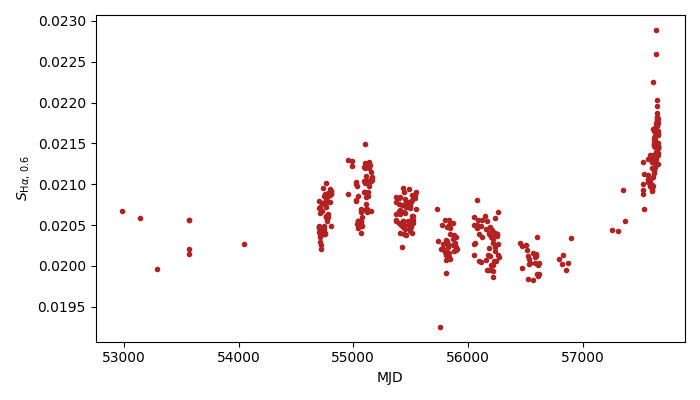

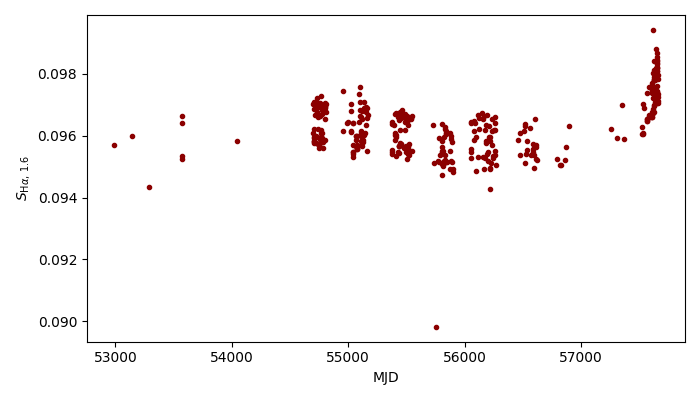

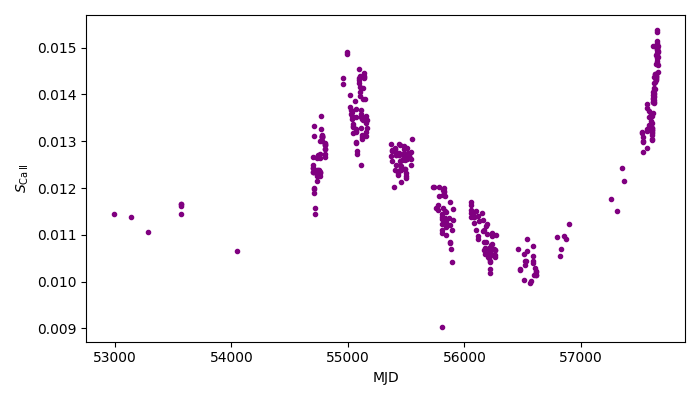


📊 Spearman correlation table (Option-1 format):

 rho(0.1)  rho(0.2)  rho(0.3)  rho(0.4)  rho(0.5)  rho(0.6)  rho(0.7)  rho(0.8)  rho(0.9)  rho(1.0)  rho(1.1)  rho(1.2)  rho(1.3)  rho(1.4)  rho(1.5)  rho(1.6)  rho(1.7)  rho(1.8)  rho(1.9)  rho(2.0)       p(0.1)        p(0.2)        p(0.3)        p(0.4)        p(0.5)        p(0.6)        p(0.7)        p(0.8)        p(0.9)        p(1.0)       p(1.1)        p(1.2)       p(1.3)       p(1.4)       p(1.5)       p(1.6)       p(1.7)       p(1.8)       p(1.9)       p(2.0)
 0.523087  0.952317  0.838429  0.954973  0.955435  0.881688  0.946379  0.882929  0.923267  0.903456  0.759146  0.849607  0.738236  0.820164   0.81192  0.641878  0.792471  0.653334  0.779704  0.769829 1.003019e-27 2.182640e-194 2.348407e-100 6.392936e-199 9.749300e-200 9.843216e-124 3.999207e-185 1.555767e-124 4.709954e-157 2.789480e-139 1.514932e-71 1.119883e-105 9.273498e-66 1.764010e-92 3.261822e-89 6.232133e-45 4.171468e-82 5.209380e-47 7.651229e-78 9.778496e-75


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.stats import spearmanr

%matplotlib widget

# ======================================================
# PATH
# ======================================================
folder_path = "/Users/abishaj/Documents/Hoststars_Activity/K_stars/HD_215152"

# ======================================================
# LINE CORES
# ======================================================
halpha_core = 6562.4
caK_core    = 3933.2
caH_core    = 3968.1

# ======================================================
# WIDTHS
# ======================================================
halpha_widths = np.round(np.arange(0.1, 2.01, 0.1), 1)   # 0.1 → 2.0 Å
ca_width = 1.09                                         # FIXED Ca II width

files = sorted([f for f in os.listdir(folder_path) if f.endswith(".fits")])

# ======================================================
# CONTAINERS
# ======================================================
time_series = {w: {"mjd": [], "halpha": []} for w in halpha_widths}
sindex_mjd  = []
sindex_vals = []

# ======================================================
# LOOP OVER SPECTRA
# ======================================================
for fname in files:
    path = os.path.join(folder_path, fname)

    try:
        with fits.open(path) as hdul:
            hdr  = hdul[0].header
            data = hdul[1].data

            mjd = hdr.get("MJD-OBS", np.nan)

            if "wavelength_air" in data.columns.names:
                wave = data["wavelength_air"]
                flux = data["flux"]
            elif "WAVE" in data.columns.names:
                wave = data["WAVE"]
                flux = data["FLUX"]
            else:
                continue

            # ==================================================
            # Ca II S-INDEX (1.09 Å)
            # ==================================================
            s_ranges = {
                "Ileft":  (3890, 3910),
                "IcoreK": (caK_core - ca_width/2, caK_core + ca_width/2),
                "IcoreH": (caH_core - ca_width/2, caH_core + ca_width/2),
                "Iright": (3990, 4010)
            }

            s_int = {k: np.sum(flux[(wave >= s) & (wave <= e)])
                     for k, (s, e) in s_ranges.items()}

            denom_s = s_int["Ileft"] + s_int["Iright"]

            if denom_s > 0:
                sindex = (s_int["IcoreK"] + s_int["IcoreH"]) / denom_s
                sindex_mjd.append(mjd)
                sindex_vals.append(sindex)

            # ==================================================
            # Hα INDICES (0.1 → 2.0 Å)
            # ==================================================
            for w in halpha_widths:
                h_ranges = {
                    "Ileft":  (6546.85, 6554.85),
                    "Icore":  (halpha_core - w/2, halpha_core + w/2),
                    "Iright": (6576.28, 6584.28)
                }

                h_int = {k: np.sum(flux[(wave >= s) & (wave <= e)])
                         for k, (s, e) in h_ranges.items()}

                denom_h = h_int["Ileft"] + h_int["Iright"]

                if denom_h > 0:
                    halpha = 2 * h_int["Icore"] / denom_h
                    time_series[w]["mjd"].append(mjd)
                    time_series[w]["halpha"].append(halpha)

    except Exception as e:
        print(f"❌ {fname}: {e}")

# ======================================================
# 🔹 COMBINE ALL INDICES INTO ONE TABLE (BY MJD)
# ======================================================
mjd_s = np.array(sindex_mjd)
sca   = np.array(sindex_vals)

all_mjd = np.unique(
    np.concatenate([mjd_s] +
                   [np.array(time_series[w]["mjd"]) for w in halpha_widths])
)

table = []

for mjd in all_mjd:
    row = {"MJD": mjd, "S_CaII": np.nan}

    if mjd in mjd_s:
        row["S_CaII"] = sca[mjd_s == mjd][0]

    for w in halpha_widths:
        key = f"S_Ha_{w:.1f}"
        row[key] = np.nan

        mjd_hw = np.array(time_series[w]["mjd"])
        sh_hw  = np.array(time_series[w]["halpha"])

        if mjd in mjd_hw:
            row[key] = sh_hw[mjd_hw == mjd][0]

    table.append(row)

# ======================================================
# 🔹 PRINT TABLE
# ======================================================
header = f"{'MJD':>12}  {'S_CaII':>10}  " + \
         "  ".join([f"S_Hα({w:.1f})".rjust(12) for w in halpha_widths])

print(header)
print("-" * len(header))

for r in table:
    line = f"{r['MJD']:12.2f}  {r['S_CaII']:10.5f}  "
    for w in halpha_widths:
        val = r[f"S_Ha_{w:.1f}"]
        line += f"{val:12.5f}  "
    print(line)

# ======================================================
# 🔹 TIME SERIES PLOTS (ONLY 0.6 & 1.6 Å)
# ======================================================
plt.figure(figsize=(7,4))
plt.plot(time_series[0.6]["mjd"], time_series[0.6]["halpha"], ".", color="firebrick")
plt.xlabel("MJD")
plt.ylabel(r"$S_{\mathrm{H}\alpha,\,0.6}$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(time_series[1.6]["mjd"], time_series[1.6]["halpha"], ".", color="darkred")
plt.xlabel("MJD")
plt.ylabel(r"$S_{\mathrm{H}\alpha,\,1.6}$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(sindex_mjd, sindex_vals, ".", color="purple")
plt.xlabel("MJD")
plt.ylabel(r"$S_{\mathrm{Ca\,II}}$")
plt.tight_layout()
plt.show()

# ======================================================
# 🔹 SPEARMAN CORRELATION (ALL WIDTHS) - NEW FORMAT
# ======================================================
rho_vals = []
p_vals   = []
valid_widths = []

for w in halpha_widths:
    mjd_h = np.array(time_series[w]["mjd"])
    sh    = np.array(time_series[w]["halpha"])

    common_mjd = np.intersect1d(mjd_s, mjd_h)

    if len(common_mjd) < 3:
        continue

    sca_c = np.array([sca[mjd_s == m][0] for m in common_mjd])
    sh_c  = np.array([sh[mjd_h == m][0] for m in common_mjd])

    rho, pval = spearmanr(sca_c, sh_c)

    valid_widths.append(w)
    rho_vals.append(rho)
    p_vals.append(pval)

# ======================================================
# 🔹 OPTION-1 FORMAT PRINT
# ======================================================
columns = (
    [f"rho({w:.1f})" for w in valid_widths] +
    [f"p({w:.1f})"   for w in valid_widths]
)

df_corr = pd.DataFrame([rho_vals + p_vals], columns=columns)

print("\n📊 Spearman correlation table (Option-1 format):\n")
print(df_corr.to_string(index=False))


In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.stats import spearmanr

# ======================================================
# CONFIG
# ======================================================
halpha_widths = np.round(np.arange(0.1, 2.01, 0.1), 1)
ca_width = 1.09

csv_file = "/Users/abishaj/Documents/Hoststars_Activity/K_STARS.csv"
parent_folder = "/Users/abishaj/Documents/Hoststars_Activity/K_stars"

output_csv = "/Users/abishaj/Documents/Hoststars_Activity/K_STARS_Index.csv"
output_spearman_csv = "/Users/abishaj/Documents/Hoststars_Activity/K_STARS_rho.csv"

# Main plot folder
plot_base = "/Users/abishaj/Documents/Hoststars_Activity/K_plots"
os.makedirs(plot_base, exist_ok=True)

# ======================================================
# READ CSV
# ======================================================
df = pd.read_csv(csv_file)

all_stars_results = []
all_spearman = []

# ======================================================
# LOOP OVER STARS
# ======================================================
for _, row in df.iterrows():

    star_name = str(row["Stars"]).strip()
    halpha_core = row["Halpha_core"]
    caK_core = row["CaK_core "]
    caH_core = row["CaH_core "]

    print(f"\n🔹 Processing {star_name}")

    star_folder = os.path.join(parent_folder, star_name)
    if not os.path.exists(star_folder):
        print("⚠️ Star folder missing")
        continue

    # Create plot subfolder
    star_plot_dir = os.path.join(plot_base, star_name)
    os.makedirs(star_plot_dir, exist_ok=True)

    # Collect FITS files
    fits_files = []
    for root, _, files in os.walk(star_folder):
        for f in files:
            if f.endswith(".fits"):
                fits_files.append(os.path.join(root, f))

    if not fits_files:
        print("⚠️ No FITS files found")
        continue

    # ======================================================
    # CONTAINERS
    # ======================================================
    time_series = {w: {"mjd": [], "halpha": []} for w in halpha_widths}
    sindex_mjd, sindex_vals = [], []

    # ======================================================
    # LOOP OVER FITS
    # ======================================================
    for path in sorted(fits_files):
        try:
            with fits.open(path) as hdul:
                hdr = hdul[0].header
                data = hdul[1].data

                mjd = hdr.get("MJD-OBS", np.nan)

                if "wavelength_air" in data.columns.names:
                    wave = data["wavelength_air"]
                    flux = data["flux"]
                elif "WAVE" in data.columns.names:
                    wave = data["WAVE"]
                    flux = data["FLUX"]
                else:
                    continue

                # ---------------- Ca II ----------------
                s_ranges = {
                    "Ileft":  (3890, 3910),
                    "IcoreK": (caK_core - ca_width/2, caK_core + ca_width/2),
                    "IcoreH": (caH_core - ca_width/2, caH_core + ca_width/2),
                    "Iright": (3990, 4010)
                }

                s_int = {k: np.sum(flux[(wave >= a) & (wave <= b)])
                         for k, (a, b) in s_ranges.items()}

                denom = s_int["Ileft"] + s_int["Iright"]
                if denom > 0:
                    sindex_mjd.append(mjd)
                    sindex_vals.append((s_int["IcoreK"] + s_int["IcoreH"]) / denom)

                # ---------------- Hα ----------------
                for w in halpha_widths:
                    h_ranges = {
                        "Ileft":  (6546.85, 6554.85),
                        "Icore":  (halpha_core - w/2, halpha_core + w/2),
                        "Iright": (6576.28, 6584.28)
                    }

                    h_int = {k: np.sum(flux[(wave >= a) & (wave <= b)])
                             for k, (a, b) in h_ranges.items()}

                    denom_h = h_int["Ileft"] + h_int["Iright"]
                    if denom_h > 0:
                        time_series[w]["mjd"].append(mjd)
                        time_series[w]["halpha"].append(2 * h_int["Icore"] / denom_h)

        except Exception as e:
            print(f"❌ {os.path.basename(path)}: {e}")

    # ======================================================
    # SAVE TABLE
    # ======================================================
    all_mjd = np.unique(
        np.concatenate([sindex_mjd] +
        [time_series[w]["mjd"] for w in halpha_widths])
    )

    for mjd in all_mjd:
        row_out = {"Star": star_name, "MJD": mjd, "S_CaII": np.nan}

        if mjd in sindex_mjd:
            row_out["S_CaII"] = sindex_vals[sindex_mjd.index(mjd)]

        for w in halpha_widths:
            key = f"S_Ha_{w:.1f}"
            row_out[key] = np.nan
            if mjd in time_series[w]["mjd"]:
                row_out[key] = time_series[w]["halpha"][time_series[w]["mjd"].index(mjd)]

        all_stars_results.append(row_out)

    # ======================================================
    # 🔹 SEPARATE TIME-SERIES PLOTS
    # ======================================================

    # --- Hα 0.6 ---
    if time_series[0.6]["mjd"]:
        plt.figure(figsize=(7,4))
        plt.plot(time_series[0.6]["mjd"], time_series[0.6]["halpha"], ".", color="firebrick")
        plt.xlabel("MJD")
        plt.ylabel(r"$S_{\mathrm{H}\alpha,\,0.6}$")
        plt.tight_layout()
        plt.savefig(os.path.join(star_plot_dir, "Halpha_0p6_timeseries.png"), dpi=200)
        plt.close()

    # --- Hα 1.6 ---
    if time_series[1.6]["mjd"]:
        plt.figure(figsize=(7,4))
        plt.plot(time_series[1.6]["mjd"], time_series[1.6]["halpha"], ".", color="darkred")
        plt.xlabel("MJD")
        plt.ylabel(r"$S_{\mathrm{H}\alpha,\,1.6}$")
        plt.tight_layout()
        plt.savefig(os.path.join(star_plot_dir, "Halpha_1p6_timeseries.png"), dpi=200)
        plt.close()

    # --- Ca II ---
    if sindex_mjd:
        plt.figure(figsize=(7,4))
        plt.plot(sindex_mjd, sindex_vals, ".", color="purple")
        plt.xlabel("MJD")
        plt.ylabel(r"$S_{\mathrm{Ca\,II}}$")
        plt.tight_layout()
        plt.savefig(os.path.join(star_plot_dir, "CaII_timeseries.png"), dpi=200)
        plt.close()

    print(f"✅ Plots saved in {star_plot_dir}")

    # ======================================================
    # SPEARMAN
    # ======================================================
    spearman_row = {"Star": star_name}
    for w in halpha_widths:
        mjd_h = np.array(time_series[w]["mjd"])
        sh = np.array(time_series[w]["halpha"])
        mjd_c = np.array(sindex_mjd)
        sc = np.array(sindex_vals)

        common = np.intersect1d(mjd_h, mjd_c)
        if len(common) < 3:
            continue

        sh_c = [sh[mjd_h == m][0] for m in common]
        sc_c = [sc[mjd_c == m][0] for m in common]

        rho, p = spearmanr(sc_c, sh_c)
        spearman_row[f"rho_{w:.1f}"] = rho
        spearman_row[f"p_{w:.1f}"] = p

    all_spearman.append(spearman_row)

# ======================================================
# SAVE CSVs
# ======================================================
pd.DataFrame(all_stars_results).to_csv(output_csv, index=False)
pd.DataFrame(all_spearman).to_csv(output_spearman_csv, index=False)

print("\n🔥 ALL DONE — indices, correlations, and plots saved cleanly")



🔹 Processing BD-08 2823
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/BD-08 2823

🔹 Processing BD-11 4672
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/BD-11 4672

🔹 Processing BD+14 4559
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/BD+14 4559

🔹 Processing GJ_86
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/GJ_86

🔹 Processing GJ_9827
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/GJ_9827

🔹 Processing HD_7199
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/HD_7199

🔹 Processing HD_8638
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/HD_8638

🔹 Processing HD_10700
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/HD_10700

🔹 Processing HD_20781
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots/HD_20781

🔹 Processing HD_21693
✅ Plots saved in /Users/abishaj/Documents/Hoststars_Activity/K_plots

In [2]:
import os
import numpy as np
import pandas as pd
from astropy.io import fits
from scipy.stats import spearmanr

# ======================================================
# CONFIG
# ======================================================
halpha_widths = np.round(np.arange(0.1, 2.01, 0.1), 1)
ca_width = 1.09

csv_file = "/Users/abishaj/Documents/Hoststars_Activity/K_STARS.csv"
parent_folder = "/Users/abishaj/Documents/Hoststars_Activity/K_stars"

base_out = "/Users/abishaj/Documents/Hoststars_Activity/NEW_RESULTS"
os.makedirs(base_out, exist_ok=True)

output_csv = os.path.join(base_out, "K_STARS_Index_NEW.csv")
output_spearman_csv = os.path.join(base_out, "K_STARS_rho_NEW.csv")

# ======================================================
# FUNCTIONS
# ======================================================
def calc_caii_and_err(wave, flux, caH_core, caK_core,
                      ca_width=1.09,
                      blue_cont=(3890, 3910),
                      red_cont=(3990, 4010)):
    """
    Calculate Ca II S-index and its error using photon noise
    """

    bands = {
        "L": blue_cont,
        "K": (caK_core - ca_width/2, caK_core + ca_width/2),
        "H": (caH_core - ca_width/2, caH_core + ca_width/2),
        "R": red_cont
    }

    F, Ferr = {}, {}

    for k, (wmin, wmax) in bands.items():
        mask = (wave >= wmin) & (wave <= wmax)
        if np.sum(mask) == 0:
            return np.nan, np.nan

        F[k] = np.sum(flux[mask])
        Ferr[k] = np.sqrt(np.abs(F[k]))  # photon noise

    denom = F["L"] + F["R"]
    if denom <= 0:
        return np.nan, np.nan

    S_caii = (F["K"] + F["H"]) / denom

    num_err2 = Ferr["K"]**2 + Ferr["H"]**2
    den_err2 = Ferr["L"]**2 + Ferr["R"]**2

    S_err = S_caii * np.sqrt(
        (num_err2 / (F["K"] + F["H"])**2) +
        (den_err2 / denom**2)
    )

    return S_caii, S_err


def integrate_flux(wave, flux, wmin, wmax):
    mask = (wave >= wmin) & (wave <= wmax)
    if np.sum(mask) == 0:
        return np.nan
    return np.sum(flux[mask])

# ======================================================
# READ STAR LIST
# ======================================================
df = pd.read_csv(csv_file)

all_results = []
all_spearman = []

# ======================================================
# LOOP OVER STARS
# ======================================================
for _, row in df.iterrows():

    star = str(row["Stars"]).strip()
    halpha_core = row["Halpha_core"]
    caK_core = row["CaK_core "]
    caH_core = row["CaH_core "]

    print(f"\n🔹 Processing {star}")

    star_folder = os.path.join(parent_folder, star)
    if not os.path.exists(star_folder):
        print("⚠️ Star folder missing")
        continue

    fits_files = []
    for root, _, files in os.walk(star_folder):
        for f in files:
            if f.endswith(".fits"):
                fits_files.append(os.path.join(root, f))

    if not fits_files:
        print("⚠️ No FITS files")
        continue

    time_series = {w: {"mjd": [], "halpha": []} for w in halpha_widths}
    sindex_mjd, sindex_vals, sindex_errs = [], [], []

    # ======================================================
    # LOOP OVER FITS
    # ======================================================
    for path in sorted(fits_files):
        try:
            with fits.open(path) as hdul:
                hdr = hdul[0].header
                data = hdul[1].data

                mjd = hdr.get("MJD-OBS", np.nan)

                # Identify wavelength & flux
                if "WAVE" in data.columns.names:
                    wave = data["WAVE"]
                    flux = data["FLUX"]
                elif "wavelength_air" in data.columns.names:
                    wave = data["wavelength_air"]
                    flux = data["flux"]
                else:
                    print(f"⚠️ Unknown FITS format: {os.path.basename(path)}")
                    continue

                # ---------- Ca II ----------
                caii, caii_err = calc_caii_and_err(
                    wave, flux, caH_core, caK_core
                )

                if np.isfinite(caii):
                    sindex_mjd.append(mjd)
                    sindex_vals.append(caii)
                    sindex_errs.append(caii_err)

                # ---------- Hα ----------
                for w in halpha_widths:
                    L = integrate_flux(wave, flux, 6546.85, 6554.85)
                    C = integrate_flux(wave, flux,
                                       halpha_core - w/2,
                                       halpha_core + w/2)
                    R = integrate_flux(wave, flux, 6576.28, 6584.28)

                    if np.isfinite(L) and np.isfinite(R) and (L + R) > 0:
                        Sh = 2 * C / (L + R)
                        time_series[w]["mjd"].append(mjd)
                        time_series[w]["halpha"].append(Sh)

        except Exception as e:
            print(f"❌ {os.path.basename(path)} : {e}")

    # ======================================================
    # MERGE OUTPUT TABLE
    # ======================================================
    all_mjd = np.unique(
        np.concatenate([sindex_mjd] +
        [time_series[w]["mjd"] for w in halpha_widths])
    )

    for mjd in all_mjd:
        row_out = {
            "Star": star,
            "MJD": mjd,
            "S_CaII": np.nan,
            "S_CaII_err": np.nan
        }

        if mjd in sindex_mjd:
            i = sindex_mjd.index(mjd)
            row_out["S_CaII"] = sindex_vals[i]
            row_out["S_CaII_err"] = sindex_errs[i]

        for w in halpha_widths:
            key = f"S_Ha_{w:.1f}"
            row_out[key] = np.nan
            if mjd in time_series[w]["mjd"]:
                idx = time_series[w]["mjd"].index(mjd)
                row_out[key] = time_series[w]["halpha"][idx]

        all_results.append(row_out)

    # ======================================================
    # SPEARMAN CORRELATION
    # ======================================================
    spearman_row = {"Star": star}

    for w in halpha_widths:
        mjd_h = np.array(time_series[w]["mjd"])
        sh = np.array(time_series[w]["halpha"])
        mjd_c = np.array(sindex_mjd)
        sc = np.array(sindex_vals)

        common = np.intersect1d(mjd_h, mjd_c)
        if len(common) < 3:
            continue

        sh_c = [sh[mjd_h == m][0] for m in common]
        sc_c = [sc[mjd_c == m][0] for m in common]

        rho, p = spearmanr(sc_c, sh_c)
        spearman_row[f"rho_{w:.1f}"] = rho
        spearman_row[f"p_{w:.1f}"] = p

    all_spearman.append(spearman_row)

# ======================================================
# SAVE OUTPUT
# ======================================================
pd.DataFrame(all_results).to_csv(output_csv, index=False)
pd.DataFrame(all_spearman).to_csv(output_spearman_csv, index=False)

print("\n🔥 DONE — Ca II (with error), Hα indices & correlations saved")


🔹 Processing BD-08 2823

🔹 Processing BD-11 4672

🔹 Processing BD+14 4559

🔹 Processing GJ_86

🔹 Processing GJ_9827

🔹 Processing HD_7199

🔹 Processing HD_8638

🔹 Processing HD_10700

🔹 Processing HD_20781

🔹 Processing HD_21693

🔹 Processing HD_21749

🔹 Processing HD_21938

🔹 Processing HD_39194

🔹 Processing HD_40397

🔹 Processing HD_45364

🔹 Processing HD_47186

🔹 Processing HD_51608

🔹 Processing HD_69830

🔹 Processing HD_85390

🔹 Processing HD_85512

🔹 Processing HD_90156

🔹 Processing HD_96700

🔹 Processing HD_154088

🔹 Processing HD_157172

🔹 Processing HD_165920

🔹 Processing HD_176986

🔹 Processing HD_181433

🔹 Processing HD_192310

🔹 Processing HD_213941

🔹 Processing HD_222669

🔹 Processing HD_215152

🔥 DONE — Ca II (with error), Hα indices & correlations saved


In [4]:
import os
import numpy as np
import pandas as pd
from astropy.io import fits
from scipy.stats import spearmanr

# ======================================================
# CONFIG
# ======================================================
halpha_widths = np.round(np.arange(0.1, 2.01, 0.1), 1)
ca_width = 1.09  # FWHM of triangular bandpass in Angstroms

csv_file      = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS - Sheet1 (1).csv"
parent_folder = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_stars"

base_out = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_NEW_RESULTS"
os.makedirs(base_out, exist_ok=True)

output_csv          = os.path.join(base_out, "K_STARS_Index_NEW.csv")
output_spearman_csv = os.path.join(base_out, "K_STARS_rho_NEW.csv")


# ======================================================
# TRIANGULAR BANDPASS FUNCTION
# ======================================================
def triangular_bandpass(wave, center, fwhm):
    """
    Returns triangular weights centred on 'center' with given FWHM.
    Weight = 1.0 at center, 0.0 at edges — Gomes da Silva+2021 method.
    """
    half    = fwhm / 2.0
    weights = np.zeros(len(wave))
    mask    = np.abs(wave - center) <= half
    weights[mask] = 1.0 - np.abs(wave[mask] - center) / half
    return weights


# ======================================================
# Ca II S-INDEX WITH TRIANGULAR BANDPASS + ERROR
# ======================================================
def calc_caii_and_err(wave, flux, caH_core, caK_core,
                      ca_width=1.09,
                      blue_cont=(3890, 3910),
                      red_cont=(3990, 4010)):
    """
    Ca II S-index using TRIANGULAR bandpass for H & K lines (FWHM=1.09A)
    and SQUARE bandpass for continuum regions (20A width).
    Reference: Gomes da Silva et al. (2021), Duncan et al. (1991).
    """
    # Triangular weights for H and K
    w_H = triangular_bandpass(wave, caH_core, ca_width)
    w_K = triangular_bandpass(wave, caK_core, ca_width)

    if np.sum(w_H > 0) == 0 or np.sum(w_K > 0) == 0:
        return np.nan, np.nan

    # Weighted flux sums
    F_H = np.sum(flux * w_H)
    F_K = np.sum(flux * w_K)

    # Photon noise errors (weighted)
    Ferr_H = np.sqrt(np.abs(np.sum(flux * w_H**2)))
    Ferr_K = np.sqrt(np.abs(np.sum(flux * w_K**2)))

    # Square bandpass for continuum
    mask_B = (wave >= blue_cont[0]) & (wave <= blue_cont[1])
    mask_R = (wave >= red_cont[0])  & (wave <= red_cont[1])

    if np.sum(mask_B) == 0 or np.sum(mask_R) == 0:
        return np.nan, np.nan

    F_B = np.sum(flux[mask_B])
    F_R = np.sum(flux[mask_R])

    Ferr_B = np.sqrt(np.abs(F_B))
    Ferr_R = np.sqrt(np.abs(F_R))

    denom = F_B + F_R
    if denom <= 0:
        return np.nan, np.nan

    S_caii = (F_H + F_K) / denom

    # Error propagation
    num_err2 = Ferr_H**2 + Ferr_K**2
    den_err2 = Ferr_B**2 + Ferr_R**2

    S_err = S_caii * np.sqrt(
        (num_err2 / (F_H + F_K)**2) +
        (den_err2 / denom**2)
    )

    return S_caii, S_err


# ======================================================
# Hα FLUX INTEGRATION (square bandpass)
# ======================================================
def integrate_flux(wave, flux, wmin, wmax):
    mask = (wave >= wmin) & (wave <= wmax)
    if np.sum(mask) == 0:
        return np.nan
    return np.sum(flux[mask])


# ======================================================
# READ FITS — handles table and 1D array formats
# ======================================================
def read_fits(path):
    """
    Returns (mjd, wave, flux) or (nan, None, None) on failure.
    Handles:
      - Table format: WAVE/FLUX or wavelength_air/flux columns
      - 1D array format: wave in ext1, flux in ext2
      - 2D arrays: takes first row
    """
    with fits.open(path) as hdul:
        hdr = hdul[0].header
        mjd = hdr.get("MJD-OBS", np.nan)

        # Try table format first
        try:
            data = hdul[1].data
            cols = data.columns.names

            if "WAVE" in cols:
                wave = np.array(data["WAVE"], dtype=float)
                flux = np.array(data["FLUX"], dtype=float)
            elif "wavelength_air" in cols:
                wave = np.array(data["wavelength_air"], dtype=float)
                flux = np.array(data["flux"], dtype=float)
            else:
                return mjd, None, None

            # Handle 2D arrays — take first row
            if wave.ndim == 2:
                wave = wave[0]
            if flux.ndim == 2:
                flux = flux[0]

            return mjd, wave, flux

        # 1D array format fallback
        except AttributeError:
            if len(hdul) >= 3:
                wave = np.array(hdul[1].data, dtype=float).flatten()
                flux = np.array(hdul[2].data, dtype=float).flatten()
                return mjd, wave, flux
            else:
                return mjd, None, None


# ======================================================
# READ STAR LIST
# ======================================================
df = pd.read_csv(csv_file)

all_results  = []
all_spearman = []

# ======================================================
# LOOP OVER STARS
# ======================================================
for _, row in df.iterrows():

    star        = str(row["star"]).strip()
    halpha_core = row["Halpha_core"]
    caK_core    = row["CaK_core "]
    caH_core    = row["CaH_core "]

    print(f"\n🔹 Processing {star}")

    star_folder = os.path.join(parent_folder, star)
    if not os.path.exists(star_folder):
        print("⚠️  Star folder missing")
        continue

    # Collect FITS files — skip Mac hidden files starting with ._
    fits_files = []
    for root, _, files in os.walk(star_folder):
        for f in files:
            if f.endswith(".fits") and not f.startswith("._"):
                fits_files.append(os.path.join(root, f))

    if not fits_files:
        print("⚠️  No FITS files found")
        continue

    time_series = {w: {"mjd": [], "halpha": []} for w in halpha_widths}
    sindex_mjd, sindex_vals, sindex_errs = [], [], []

    # ======================================================
    # LOOP OVER FITS FILES
    # ======================================================
    for path in sorted(fits_files):
        try:
            mjd, wave, flux = read_fits(path)

            if wave is None or flux is None:
                print(f"⚠️  Unknown format: {os.path.basename(path)}")
                continue

            # ---------- Ca II (triangular bandpass) ----------
            caii, caii_err = calc_caii_and_err(
                wave, flux, caH_core, caK_core, ca_width=ca_width
            )

            if np.isfinite(caii):
                sindex_mjd.append(mjd)
                sindex_vals.append(caii)
                sindex_errs.append(caii_err)

            # ---------- Hα (square bandpass) ----------
            for w in halpha_widths:
                L = integrate_flux(wave, flux, 6546.85, 6554.85)
                C = integrate_flux(wave, flux,
                                   halpha_core - w/2,
                                   halpha_core + w/2)
                R = integrate_flux(wave, flux, 6576.28, 6584.28)

                if np.isfinite(L) and np.isfinite(R) and (L + R) > 0:
                    Sh = 2 * C / (L + R)
                    time_series[w]["mjd"].append(mjd)
                    time_series[w]["halpha"].append(Sh)

        except Exception as e:
            print(f"❌ {os.path.basename(path)} : {e}")

    # ======================================================
    # MERGE OUTPUT TABLE
    # ======================================================
    all_mjd_list   = [sindex_mjd] + [time_series[w]["mjd"] for w in halpha_widths]
    all_mjd_concat = [m for sub in all_mjd_list for m in sub]

    if not all_mjd_concat:
        print(f"⚠️  No valid data for {star}")
        continue

    all_mjd = np.unique(all_mjd_concat)

    for mjd in all_mjd:
        row_out = {
            "Star"       : star,
            "MJD"        : mjd,
            "S_CaII"     : np.nan,
            "S_CaII_err" : np.nan
        }

        if mjd in sindex_mjd:
            i = sindex_mjd.index(mjd)
            row_out["S_CaII"]     = sindex_vals[i]
            row_out["S_CaII_err"] = sindex_errs[i]

        for w in halpha_widths:
            key = f"S_Ha_{w:.1f}"
            row_out[key] = np.nan
            if mjd in time_series[w]["mjd"]:
                idx = time_series[w]["mjd"].index(mjd)
                row_out[key] = time_series[w]["halpha"][idx]

        all_results.append(row_out)

    # ======================================================
    # SPEARMAN CORRELATION
    # ======================================================
    spearman_row = {"Star": star}

    for w in halpha_widths:
        mjd_h = np.array(time_series[w]["mjd"])
        sh    = np.array(time_series[w]["halpha"])
        mjd_c = np.array(sindex_mjd)
        sc    = np.array(sindex_vals)

        common = np.intersect1d(mjd_h, mjd_c)
        if len(common) < 3:
            continue

        sh_c = [sh[mjd_h == m][0] for m in common]
        sc_c = [sc[mjd_c == m][0] for m in common]

        rho, p = spearmanr(sc_c, sh_c)
        spearman_row[f"rho_{w:.1f}"] = rho
        spearman_row[f"p_{w:.1f}"]   = p

    all_spearman.append(spearman_row)

# ======================================================
# SAVE OUTPUT
# ======================================================
pd.DataFrame(all_results).to_csv(output_csv, index=False)
pd.DataFrame(all_spearman).to_csv(output_spearman_csv, index=False)

print("\n✅ DONE — Results saved to:", base_out)


🔹 Processing BD-08 2823

🔹 Processing BD-11 4672

🔹 Processing BD+14 4559

🔹 Processing GJ_86

🔹 Processing GJ_9827

🔹 Processing HD_7199

🔹 Processing HD_8638

🔹 Processing HD_10700

🔹 Processing HD_20781

🔹 Processing HD_21693

🔹 Processing HD_21749

🔹 Processing HD_21938

🔹 Processing HD_39194

🔹 Processing HD_40397

🔹 Processing HD_45364

🔹 Processing HD_47186

🔹 Processing HD_51608

🔹 Processing HD_69830

🔹 Processing HD_85390

🔹 Processing HD_85512

🔹 Processing HD_90156

🔹 Processing HD_96700

🔹 Processing HD_154088

🔹 Processing HD_157172

🔹 Processing HD_165920

🔹 Processing HD_176986

🔹 Processing HD_181433

🔹 Processing HD_192310

🔹 Processing HD_213941

🔹 Processing HD_222669

🔹 Processing HD_215152

✅ DONE — Results saved to: /Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_NEW_RESULTS


In [5]:
import numpy as np
import pandas as pd

# ======================================================
# CALIBRATION FUNCTION
# ======================================================
def calc_smw(caii, caii_err, instr='HARPS_GDS21'):
    caii     = np.asarray(caii,     dtype=float)
    caii_err = np.asarray(caii_err, dtype=float)

    if instr == 'ESPRESSO':
        a, b = 1.222, 0.001
    elif instr == 'HARPS_L11':
        a, b = 1.111, 0.0153
    elif instr == 'HARPS_GDS21':
        a, b = 1.195, 0.008
    else:
        raise ValueError("Unknown instrument")

    smw     = a * caii + b
    smw_err = a * caii_err

    return smw, smw_err


# ======================================================
# INPUT / OUTPUT
# ======================================================
input_csv  = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS - Sheet5.csv"
output_csv = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_smw.csv"
output_grouped_csv = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_smw_grouped.csv"

df = pd.read_csv(input_csv)


# ======================================================
# ROBUST PARSER
# ======================================================
def split_to_float_array(x):
    if pd.isna(x):
        return np.array([])

    if isinstance(x, str):
        vals = []
        for i in x.split(","):
            i = i.strip()
            if i == "":
                continue
            try:
                vals.append(float(i))
            except ValueError:
                print(f"⚠️ Skipping bad value: {i}")
        return np.array(vals)

    # single numeric value
    return np.array([float(x)])


# ======================================================
# FLATTEN DATA (SAFE)
# ======================================================
stars_all    = []
caii_all     = []
caii_err_all = []

for idx, row in df.iterrows():
    star = row.get("Star", f"Row_{idx}")

    caii_vals = split_to_float_array(row.get("S_CaII"))
    err_vals  = split_to_float_array(row.get("S_CaII_err"))

    # skip empty rows
    if len(caii_vals) == 0 or len(err_vals) == 0:
        print(f"⚠️ Skipping empty data for {star}")
        continue

    # fix mismatch instead of crashing
    if len(caii_vals) != len(err_vals):
        min_len = min(len(caii_vals), len(err_vals))
        print(f"⚠️ Length mismatch for {star} → trimming to {min_len}")
        caii_vals = caii_vals[:min_len]
        err_vals  = err_vals[:min_len]

    stars_all.extend([star] * len(caii_vals))
    caii_all.extend(caii_vals)
    caii_err_all.extend(err_vals)

# convert to arrays
stars_all    = np.array(stars_all)
caii_all     = np.array(caii_all)
caii_err_all = np.array(caii_err_all)


# ======================================================
# CALCULATE SMW
# ======================================================
smw, smw_err = calc_smw(
    caii_all,
    caii_err_all,
    instr="HARPS_GDS21"
)


# ======================================================
# SAVE LONG FORMAT OUTPUT (one row per observation)
# ======================================================
out_df = pd.DataFrame({
    "Star"       : stars_all,
    "S_CaII"     : caii_all,
    "S_CaII_err" : caii_err_all,
    "S_MW"       : smw,
    "S_MW_err"   : smw_err
})

out_df.to_csv(output_csv, index=False)
print(f"✅ Long format saved  → {output_csv}")
print(f"✅ Total measurements : {len(out_df)}")


# ======================================================
# SAVE GROUPED OUTPUT (one row per star) ← NEW
# ======================================================
value_cols = [c for c in out_df.columns if c != "Star"]

grouped = out_df.groupby("Star", sort=False)[value_cols].agg(
    lambda x: ", ".join([str(round(v, 10)) if pd.notna(v) else "" for v in x])
).reset_index()

grouped.to_csv(output_grouped_csv, index=False)
print(f"✅ Grouped format saved → {output_grouped_csv}")
print(f"✅ Total stars          : {len(grouped)}")

✅ Long format saved  → /Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_smw.csv
✅ Total measurements : 4479
✅ Grouped format saved → /Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_smw_grouped.csv
✅ Total stars          : 31


In [8]:
import pandas as pd
import numpy as np

# ======================================================
# READ CSV
# ======================================================
df = pd.read_csv("/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_smw_grouped.csv")   # <-- your file

# ======================================================
# FUNCTION TO COMPUTE MEAN FROM COMMA-SEPARATED STRINGS
# ======================================================
def mean_from_string(x):
    try:
        values = [float(i) for i in str(x).split(",")]
        return np.mean(values)
    except:
        return np.nan

# ======================================================
# APPLY MEAN
# ======================================================
df["S_MW_mean"] = df["S_MW"].apply(mean_from_string)
df["S_MW_err_mean"] = df["S_MW_err"].apply(mean_from_string)

# ======================================================
# SAVE OUTPUT
# ======================================================
df.to_csv("/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_mean_SMW.csv", index=False)

print("✅ Mean S_MW and S_MW_err calculated and saved")


✅ Mean S_MW and S_MW_err calculated and saved


In [9]:
import numpy as np
import pandas as pd

# ======================================================
# INPUT / OUTPUT
# ======================================================
csv_file = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS - Sheet5 (1).csv"
output_file = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_output_rhk.csv"

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_csv(csv_file)

# ======================================================
# FUNCTION: AUTO logR'HK
# ======================================================
def calc_rhk_auto(smw, smw_err, bv, evstage='MS'):

    smw = np.asarray(smw, dtype=float)
    smw_err = np.asarray(smw_err, dtype=float)
    bv = np.asarray(bv, dtype=float)

    n = len(bv)

    log_ccf_arr = np.full(n, np.nan)
    ccf_arr = np.full(n, np.nan)
    r_arr = np.full(n, np.nan)
    rphot_arr = np.full(n, np.nan)
    rhk_arr = np.full(n, np.nan)
    log_rhk_arr = np.full(n, np.nan)
    log_rhk_err_arr = np.full(n, np.nan)
    method_used = np.full(n, "", dtype=object)

    for i in range(n):

        bvi = bv[i]
        Si = smw[i]
        Si_err = smw_err[i]

        # --------------------------------------------------
        # METHOD SELECTION
        # --------------------------------------------------
        if evstage == 'MS':
            if 0.44 < bvi < 1.20:
                method = 'middelkoop'
            elif 0.40 <= bvi <= 1.90:
                method = 'mascareno'
            elif 0.30 <= bvi <= 1.60:
                method = 'rutten'
            else:
                continue
        else:
            if 0.30 <= bvi <= 1.70:
                method = 'rutten'
            else:
                continue

        method_used[i] = method

        # --------------------------------------------------
        # log Ccf
        # --------------------------------------------------
        if method == 'middelkoop':
            logCcf = 1.13*bvi**3 - 3.91*bvi**2 + 2.84*bvi - 0.47
            if bvi < 0.63:
                logCcf += (
                    0.135*(0.63-bvi)
                    - 0.814*(0.63-bvi)**2
                    + 6.03*(0.63-bvi)**3
                )

        elif method == 'rutten':
            if evstage == 'MS':
                logCcf = 0.25*bvi**3 - 1.33*bvi**2 + 0.43*bvi + 0.24
            else:
                logCcf = -0.066*bvi**3 - 0.25*bvi**2 - 0.49*bvi + 0.45

        elif method == 'mascareno':
            logCcf = 0.668 - 1.270*bvi + 0.645*bvi**2 - 0.443*bvi**3
        else:
            continue

        log_ccf_arr[i] = logCcf
        Ccf = 10**logCcf
        ccf_arr[i] = Ccf

        # --------------------------------------------------
        # R_HK
        # --------------------------------------------------
        r = 1.34e-4 * Ccf * Si
        r_err = 1.34e-4 * Ccf * Si_err
        r_arr[i] = r

        # --------------------------------------------------
        # Photospheric correction
        # --------------------------------------------------
        if method in ('middelkoop', 'rutten'):
            log_rphot = -4.898 + 1.918*bvi**2 - 2.893*bvi**3
            rphot = 10**log_rphot
        else:
            rphot = 1.48e-4 * np.exp(-4.3658 * bvi)

        rphot_arr[i] = rphot

        # --------------------------------------------------
        # FINAL R'HK
        # --------------------------------------------------
        if r > rphot:
            rhk = r - rphot
            rhk_arr[i] = rhk
            log_rhk_arr[i] = np.log10(rhk)
            log_rhk_err_arr[i] = r_err / (rhk * np.log(10))

    return (
        log_ccf_arr,
        ccf_arr,
        r_arr,
        rphot_arr,
        rhk_arr,
        log_rhk_arr,
        log_rhk_err_arr,
        method_used
    )

# ======================================================
# RUN CALCULATION
# ======================================================
log_ccf, ccf, r, rphot, rhk, log_rhk, log_rhk_err, method = calc_rhk_auto(
    smw=df["S_MW_mean"],
    smw_err=df["S_MW_err_mean"],
    bv=df["B-V"],
    evstage="MS"
)

# ======================================================
# SAVE OUTPUT
# ======================================================
df["log_ccf"] = log_ccf
df["ccf"] = ccf
df["r"] = r
df["rphot"] = rphot
df["rhk"] = rhk
df["log_rhk"] = log_rhk
df["log_rhk_err"] = log_rhk_err
df["method"] = method

df.to_csv(output_file, index=False)

print("✅ logCcf, Ccf, r, rphot, rhk, logR'HK saved to:", output_file)

✅ logCcf, Ccf, r, rphot, rhk, logR'HK saved to: /Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_output_rhk.csv


In [12]:
import pandas as pd
import numpy as np

# -----------------------------
# Input CSV file
# -----------------------------
input_csv = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_output_rhk.csv"   # Replace with your CSV path
output_csv = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_OUTPUT_LOG_RHK.csv" # CSV to save results

# -----------------------------
# Read the CSV
# -----------------------------
df = pd.read_csv(input_csv)

# Make sure the necessary columns exist
required_cols = ['Star', 'B-V', 'S_MW_mean', 'ccf', 'rphot']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' is missing in the CSV!")

# -----------------------------
# Compute R_HK, R'_HK, log R'_HK
# -----------------------------
df['R_HK'] = 1.34e-4 * df['ccf'] * df['S_MW_mean']
df['R_HK_prime'] = df['R_HK'] - df['rphot']
df['log_R_HK_prime'] = np.log10(np.abs(df['R_HK_prime']))

# -----------------------------
# Print results
# -----------------------------
for idx, row in df.iterrows():
    print(f"Star       = {row['Star']}")
    print(f"R_HK       = {row['R_HK']:.3e}")
    print(f"R'_HK      = {row['R_HK_prime']:.3e}")
    print(f"log R'_HK  = {row['log_R_HK_prime']:.3f}")
    print("-"*30)

# -----------------------------
# Save to CSV
# -----------------------------
df.to_csv(output_csv, index=False)
print(f"\nResults saved to {output_csv}")

Star       = BD-08 2823
R_HK       = 1.043e-06
R'_HK      = 4.449e-07
log R'_HK  = -6.352
------------------------------
Star       = BD-11 4672
R_HK       = 9.257e-07
R'_HK      = 2.061e-07
log R'_HK  = -6.686
------------------------------
Star       = BD+14 4559
R_HK       = 4.920e-08
R'_HK      = -8.134e-08
log R'_HK  = -7.090
------------------------------
Star       = GJ_86
R_HK       = 1.333e-06
R'_HK      = -4.620e-06
log R'_HK  = -5.335
------------------------------
Star       = GJ_9827
R_HK       = 3.077e-07
R'_HK      = 6.607e-08
log R'_HK  = -7.180
------------------------------
Star       = HD_7199
R_HK       = 1.072e-06
R'_HK      = -3.719e-06
log R'_HK  = -5.430
------------------------------
Star       = HD_8638
R_HK       = 1.821e-06
R'_HK      = -1.198e-05
log R'_HK  = -4.922
------------------------------
Star       = HD_10700
R_HK       = 1.527e-06
R'_HK      = -8.859e-06
log R'_HK  = -5.053
------------------------------
Star       = HD_20781
R_HK       = 1.147e-0

In [1]:
# Stellar Age Calculator from CSV file
# Based on Tucci Maia et al. (2016)
# Formula: Age = 4.50 - 24.18 * [Y/Mg]

import pandas as pd
import sys

# -----------------------------------------------
# EDIT THIS: your CSV file path
CSV_FILE = "/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS - Sheet1 (1).csv"

# EDIT THIS: column name for [Y/Mg] in your CSV
YMG_COLUMN = "Y/Mg"
# -----------------------------------------------

def calculate_age(ymg):
    return 4.50 - 24.18 * ymg


def main():
    # Load CSV
    try:
        df = pd.read_csv(CSV_FILE)
    except FileNotFoundError:
        print(f"ERROR: File '{CSV_FILE}' not found.")
        print("Please edit CSV_FILE variable in the script.")
        sys.exit(1)

    print(f"Loaded '{CSV_FILE}' — {len(df)} rows found.")
    print(f"Columns available: {list(df.columns)}\n")

    # Check column exists
    if YMG_COLUMN not in df.columns:
        print(f"ERROR: Column '{YMG_COLUMN}' not found in CSV.")
        print(f"Available columns: {list(df.columns)}")
        print("Please edit the YMG_COLUMN variable in the script.")
        sys.exit(1)

    # Convert column to numeric (fixes string/object type errors)
    df[YMG_COLUMN] = pd.to_numeric(df[YMG_COLUMN], errors="coerce")

    # Warn if any values could not be converted
    bad = df[YMG_COLUMN].isna().sum()
    if bad > 0:
        print(f"WARNING: {bad} rows had non-numeric values in '{YMG_COLUMN}' — they will be skipped.\n")

    # Calculate age
    df["Age_Gyr"]       = df[YMG_COLUMN].apply(lambda x: calculate_age(x) if pd.notna(x) else None)
    df["Age_Myr"]       = df["Age_Gyr"] * 1000
    df["Age_Error_Gyr"] = 0.80   # ± 0.80 Gyr from Tucci Maia 2016

    # Save output
    output_file = CSV_FILE.replace(".csv", "_with_ages.csv")
    df.to_csv(output_file, index=False)

    # Print results
    print("=" * 55)
    print(f"  {'[Y/Mg]':>10}  {'Age (Gyr)':>16}  {'Age (Myr)':>10}")
    print("=" * 55)
    for _, row in df.iterrows():
        ymg = row[YMG_COLUMN]
        age = row["Age_Gyr"]
        myr = row["Age_Myr"]
        age_str = "< 0 (very young)" if age < 0 else f"{age:.2f} ± 0.80"
        print(f"  {ymg:>10.3f}  {age_str:>16}  {myr:>10.0f}")
    print("=" * 55)

    print(f"\nResults saved to: {output_file}")


if __name__ == "__main__":
    main()

Loaded '/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS - Sheet1 (1).csv' — 31 rows found.
Columns available: ['star', 'Host_star', 'Fe/H', 'log_g', 'Y/Mg', 'Halpha_core', 'CaK_core ', 'CaH_core ', 'B-V', 'Teff', 'MJD', 'S_CaII', 'S_CaII_err', 'S_MW', 'S_MW_err', 'S_MW_mean', 'S_MW_err_mean', 'S_Ha_0.1', 'S_Ha_0.2', 'S_Ha_0.3', 'S_Ha_0.4', 'S_Ha_0.5', 'S_Ha_0.6', 'S_Ha_0.7', 'S_Ha_0.8', 'S_Ha_0.9', 'S_Ha_1.0', 'S_Ha_1.1', 'S_Ha_1.2', 'S_Ha_1.3', 'S_Ha_1.4', 'S_Ha_1.5', 'S_Ha_1.6', 'S_Ha_1.7', 'S_Ha_1.8', 'S_Ha_1.9', 'S_Ha_2.0', 'rho_0.1', 'p_0.1', 'rho_0.2', 'p_0.2', 'rho_0.3', 'p_0.3', 'rho_0.4', 'p_0.4', 'rho_0.5', 'p_0.5', 'rho_0.6', 'p_0.6', 'rho_0.7', 'p_0.7', 'rho_0.8', 'p_0.8', 'rho_0.9', 'p_0.9', 'rho_1.0', 'p_1.0', 'rho_1.1', 'p_1.1', 'rho_1.2', 'p_1.2', 'rho_1.3', 'p_1.3', 'rho_1.4', 'p_1.4', 'rho_1.5', 'p_1.5', 'rho_1.6', 'p_1.6', 'rho_1.7', 'p_1.7', 'rho_1.8', 'p_1.8', 'rho_1.9', 'p_1.9', 'rho_2.0', 'p_2.0', 'ccf', 'r', 'rphot', 'R_HK', 'R_HK_prime', "logR'HK"]


    

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

df = pd.read_csv('/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS.csv')

def parse_vals(s):
    result = []
    for x in str(s).split(','):
        x = x.strip()
        if x:
            try:
                result.append(float(x))
            except:
                pass
    return result

# Explode comma-separated time series into rows
rows = []
for _, row in df.iterrows():
    star = row['Star']
    mjd_vals   = parse_vals(row['MJD'])
    scaii_vals = parse_vals(row['S_CaII'])
    ha06_vals  = parse_vals(row['S_Ha_0.6'])
    ha16_vals  = parse_vals(row['S_Ha_1.6'])
    n = min(len(mjd_vals), len(scaii_vals), len(ha06_vals), len(ha16_vals))
    for i in range(n):
        rows.append({
            'Star'    : star,
            'MJD'     : mjd_vals[i],
            'S_CaII'  : scaii_vals[i],
            'S_Ha_0.6': ha06_vals[i],
            'S_Ha_1.6': ha16_vals[i],
        })

data = pd.DataFrame(rows)
stars = list(df['Star'])          # preserve original order

cols_info = [
    ('S_CaII',   r'S$_{CaII}$',           '#c778dd'),
    ('S_Ha_0.6', r'S$_{H\alpha}$ (0.6 Å)', '#58a6ff'),
    ('S_Ha_1.6', r'S$_{H\alpha}$ (1.6 Å)', '#3fb950'),
]

n_stars = len(stars)
fig, axes = plt.subplots(n_stars, 3, figsize=(18, n_stars * 3),
                          constrained_layout=True)
fig.patch.set_facecolor('#0d1117')

for i, star in enumerate(stars):
    sub = data[data['Star'] == star].sort_values('MJD')
    for j, (col, ylabel, color) in enumerate(cols_info):
        ax = axes[i, j]
        ax.set_facecolor('#0d1117')
        ax.scatter(sub['MJD'], sub[col], s=10, color=color, alpha=0.85, linewidths=0)
        ax.tick_params(colors='#c9d1d9', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363d')
        ax.grid(True, color='#21262d', linewidth=0.5, linestyle='--')

        # Column headers on top row only
        if i == 0:
            ax.set_title(ylabel, color='#e6edf3', fontsize=11, fontweight='bold', pad=8)

        # X label on bottom row only
        if i == n_stars - 1:
            ax.set_xlabel('MJD', fontsize=9, color='#c9d1d9')

        # Star name + y-label on left column only
        if j == 0:
            ax.set_ylabel(f'{star}\n{ylabel}', fontsize=9, color='#e6edf3')
        else:
            ax.set_ylabel(ylabel, fontsize=9, color='#c9d1d9')

fig.suptitle('K Stars — Activity Indices vs MJD', fontsize=16,
             color='#e6edf3', fontweight='bold')

plt.savefig('/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/K_STARS_per_star.png', dpi=130, bbox_inches='tight',
            facecolor='#0d1117')
print("Saved: K_STARS_per_star.png")

Saved: K_STARS_per_star.png
